Tomando como base la libreta de kaggle de [Anomaly Detection using PatchCore from Scratch](https://www.kaggle.com/code/akshaysom/anomaly-detection-using-patchcore-from-scratch) pero cambiando el conjunto de dataset del `hazelnut` al `grid`

In [1]:
import os, shutil
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torchvision.models import resnet50, ResNet50_Weights

In [2]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [3]:
class resnet_feature_extractor(torch.nn.Module):
    def __init__(self):
        """This class extracts the feature maps from a pretrained Resnet model."""
        super(resnet_feature_extractor, self).__init__()
        self.model = resnet50(weights=ResNet50_Weights.DEFAULT)

        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False

        
        # Hook to extract feature maps
        def hook(module, input, output) -> None:
            """This hook saves the extracted feature map on self.featured."""
            self.features.append(output)

        self.model.layer2[-1].register_forward_hook(hook)            
        self.model.layer3[-1].register_forward_hook(hook) 

    def forward(self, input):

        self.features = []
        with torch.no_grad():
            _ = self.model(input)

        self.avg = torch.nn.AvgPool2d(3, stride=1)
        fmap_size = self.features[0].shape[-2]         # Feature map sizes h, w
        self.resize = torch.nn.AdaptiveAvgPool2d(fmap_size)

        resized_maps = [self.resize(self.avg(fmap)) for fmap in self.features]
        patch = torch.cat(resized_maps, 1)            # Merge the resized feature maps
        patch = patch.reshape(patch.shape[1], -1).T   # Craete a column tensor

        return patch

torch.Size([1, 512, 28, 28])
torch.Size([1, 1024, 14, 14])
torch.Size([784, 1536])


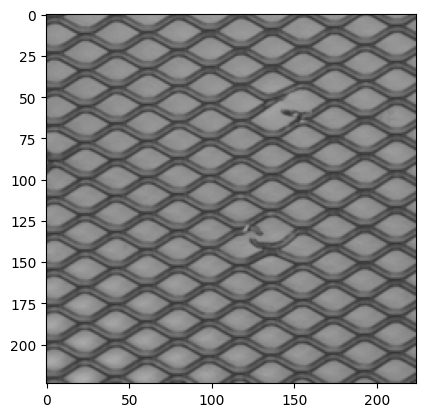

In [ ]:
backbone = resnet_feature_extractor().cuda()

sample_img_path = '/home/jamor/redes/MVTec-AD/data/raw/grid/test/broken/000.png'
image = Image.open(sample_img_path).convert("RGB")
image = transform(image).unsqueeze(0).cuda()

feature = backbone(image)

print(backbone.features[0].shape)
print(backbone.features[1].shape)

print(feature.shape)

plt.imshow(image[0].cpu().permute(1,2,0), cmap='gray')
plt.show()

In [22]:
memory_bank = []

folder_path = Path(r'/home/jamor/redes/MVTec-AD/data/raw/grid/train/good')

for pth in tqdm(folder_path.iterdir(),leave=False):
    # print(pth)
    with torch.no_grad():
        data = transform(Image.open(pth).convert("RGB")).cuda().unsqueeze(0)
        features = backbone(data)
        # print(features.shape)
        memory_bank.append(features.cpu().detach())

print(len(memory_bank))
print(memory_bank[0].shape)
memory_bank = torch.cat(memory_bank,dim=0).cuda()
memory_bank.shape # 784x391 = 306544

0it [00:00, ?it/s]

264
torch.Size([784, 1536])


torch.Size([206976, 1536])

In [23]:
selected_indices = np.random.choice(len(memory_bank), size=len(memory_bank)//10, replace=False)
memory_bank = memory_bank[selected_indices]
memory_bank.shape

torch.Size([20697, 1536])

In [24]:
y_score_good = []
folder_path = Path(r'/home/jamor/redes/MVTec-AD/data/raw/grid/train/good')

for pth in tqdm(folder_path.iterdir(),leave=False):
    data = transform(Image.open(pth).convert("RGB")).cuda().unsqueeze(0)
    # print(data.shape)
    with torch.no_grad():
        features = backbone(data)
        # print(features.shape)
    distances = torch.cdist(features, memory_bank, p=2.0)
    # print(distances.shape)
    dist_score, dist_score_idxs = torch.min(distances, dim=1) 
    # print(dist_score[:10], dist_score_idxs[:10])
    s_star = torch.max(dist_score)
    # print(s_star)
    segm_map = dist_score.view(1, 1, 28, 28) 
    # print(segm_map.shape)

    y_score_good.append(s_star.cpu().numpy())
    # break

y_score_good[:5]

0it [00:00, ?it/s]

[array(8.486519, dtype=float32),
 array(8.40821, dtype=float32),
 array(11.051128, dtype=float32),
 array(8.503834, dtype=float32),
 array(9.719032, dtype=float32)]

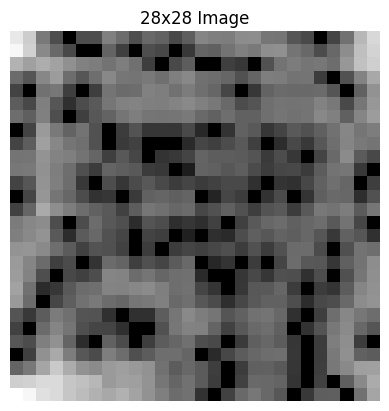

In [25]:
image_np = segm_map.squeeze().cpu() # Remove batch & channel dimensions

# Plot the image
plt.imshow(image_np, cmap='gray')
plt.title("28x28 Image")
plt.axis("off")  # Hide axes
plt.show()

9.949801
0.99399626
Threshold: 12.931790351867676


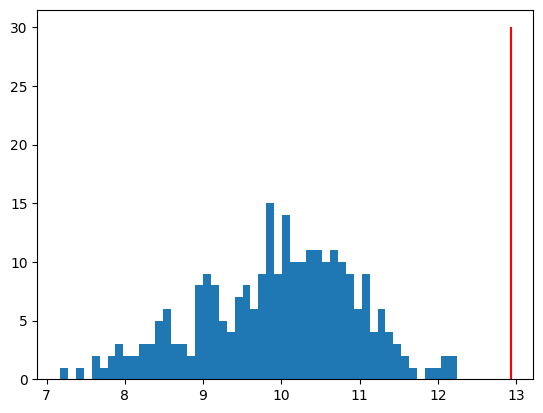

In [26]:
print(np.mean(y_score_good))
print(np.std(y_score_good))

best_threshold = np.mean(y_score_good) + 3 * np.std(y_score_good)
print(f"Threshold: {best_threshold}")

plt.hist(y_score_good, bins=50)
plt.vlines(x=best_threshold, ymin=0, ymax=30, color='r')
plt.show()

In [30]:
y_score = []
y_true = []
path = "/home/jamor/redes/MVTec-AD/data/raw/grid/test"
contents = os.listdir(path)
for classes in contents:
    folder_path_test = Path(f"{path}/{classes}")
    
    for pth in tqdm(folder_path_test.iterdir(),leave=False):
        # print(pth)
        class_label = pth.parts[-2]
        # print(class_label)
        with torch.no_grad():
            test_image = transform(Image.open(pth).convert("RGB")).cuda().unsqueeze(0)
            features = backbone(test_image)

        distances = torch.cdist(features, memory_bank, p=2.0)
        dist_score, dist_score_idxs = torch.min(distances, dim=1) 
        s_star = torch.max(dist_score)
        segm_map = dist_score.view(1, 1, 28, 28) 

        y_score.append(s_star.cpu().numpy())
        y_true.append(0 if class_label=='good' else 1)  # 0 -> GOOD, 1 -> BAD
        # break

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [31]:
y_score[40:45], y_true[40:45]

([array(15.617389, dtype=float32),
  array(15.212095, dtype=float32),
  array(12.452973, dtype=float32),
  array(13.8108425, dtype=float32),
  array(19.505852, dtype=float32)],
 [1, 1, 1, 1, 1])

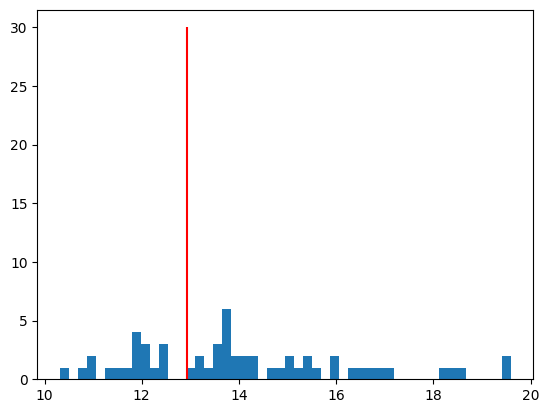

In [32]:
y_score_bad = [score for score,true in zip(y_score, y_true) if true==1]
plt.hist(y_score_bad,bins=50)
plt.vlines(x=best_threshold,ymin=0,ymax=30,color='r')
plt.show()

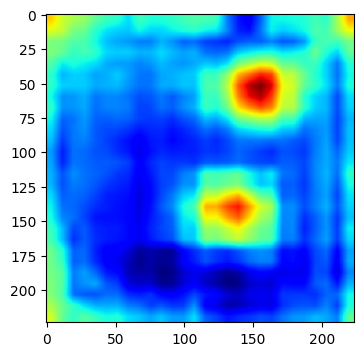

In [35]:
test_image = transform(Image.open(f'{path}/broken/000.png').convert("RGB")).cuda().unsqueeze(0)
features = backbone(test_image)

distances = torch.cdist(features, memory_bank, p=2.0)
dist_score, dist_score_idxs = torch.min(distances, dim=1) 
s_star = torch.max(dist_score)
segm_map = dist_score.view(1, 1, 28, 28)

# Upscale by bi-linaer interpolation to match the original input resolution
segm_map = torch.nn.functional.interpolate(
                segm_map,
                size=(224, 224),
                mode='bilinear'
                )
plt.figure(figsize=(4,4))
plt.imshow(segm_map.cpu().squeeze(), cmap='jet')
plt.show()

AUC-ROC Score: 0.9114452798663325
fpr, tpr, thresholds:  [0.         0.         0.         0.04761905 0.04761905 0.0952381
 0.0952381  0.14285714 0.14285714 0.19047619 0.19047619 0.42857143
 0.42857143 0.47619048 0.47619048 0.52380952 0.52380952 0.9047619
 0.9047619  1.        ] [0.         0.01754386 0.56140351 0.56140351 0.66666667 0.66666667
 0.85964912 0.85964912 0.87719298 0.87719298 0.89473684 0.89473684
 0.9122807  0.9122807  0.92982456 0.92982456 0.98245614 0.98245614
 1.         1.        ] [        inf 19.59451675 13.69504738 13.67609787 13.20961857 12.94703579
 11.92307281 11.90869522 11.83439255 11.72670078 11.65387249 11.48556042
 11.43285656 11.33909512 11.26748848 11.06851768 10.83613777 10.31748772
 10.31634617 10.11802292]
f1_scores: [0.0, 0.034482758620689655, 0.7191011235955056, 0.7111111111111111, 0.7916666666666666, 0.7835051546391752, 0.9074074074074074, 0.8990825688073395, 0.9090909090909091, 0.9009009009009009, 0.9107142857142857, 0.8717948717948718, 0.881355932

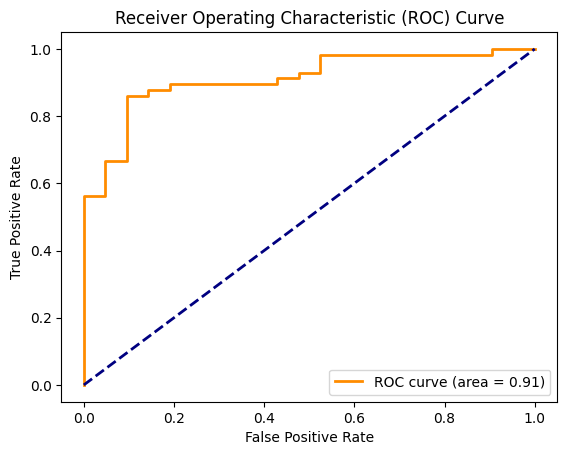

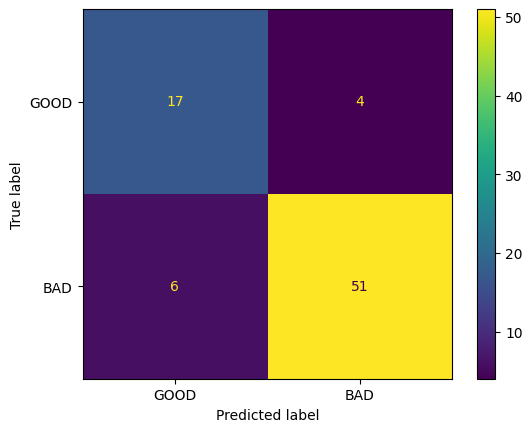

In [36]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, f1_score

# Calculate AUC-ROC score
auc_roc_score = roc_auc_score(y_true, y_score)
print("AUC-ROC Score:", auc_roc_score)

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_score)
print("fpr, tpr, thresholds: ", fpr, tpr, thresholds)

f1_scores = [f1_score(y_true, y_score >= threshold) for threshold in thresholds]
print("f1_scores:", f1_scores)

# Select the best threshold based on F1 score
best_threshold = thresholds[np.argmax(f1_scores)]

print(f'best_threshold = {best_threshold}')

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_roc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Generate confusion matrix
cm = confusion_matrix(y_true, (y_score >= best_threshold).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['GOOD', 'BAD'])
disp.plot()
plt.show()

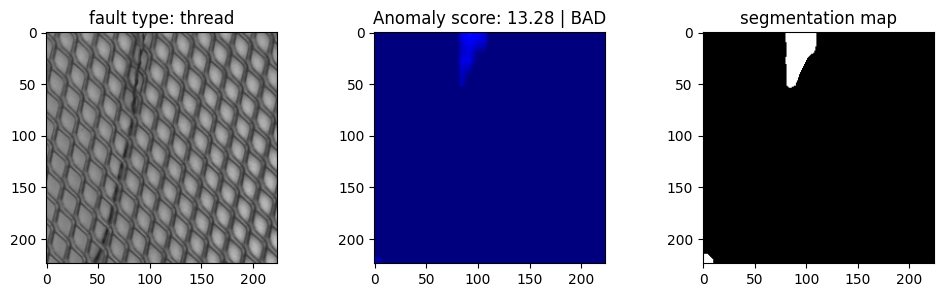

In [ ]:
import cv2, time
from IPython.display import clear_output

backbone.eval()
class_label = ['GOOD', 'BAD']
path = "/home/jamor/redes/MVTec-AD/data/raw/grid/test"
contents = os.listdir(path)
test_path = Path(path)

for path in test_path.glob('*/*.png'): 

    fault_type = path.parts[-2]
    if fault_type in [contents[0]]: # de 0 a 5, ['thread', 'bent', 'glue', 'broken', 'metal_contamination', 'good']
        
        test_image = transform(Image.open(path).convert('RGB')).cuda().unsqueeze(0)
        
        with torch.no_grad():
            features = backbone(test_image)
        # Forward pass
        distances = torch.cdist(features, memory_bank, p=2.0)
        dist_score, dist_score_idxs = torch.min(distances, dim=1) 
        s_star = torch.max(dist_score)
        segm_map = dist_score.view(1, 1, 28, 28) 
        # Upscale by bi-linear interpolation to match the original input resolution
        segm_map = torch.nn.functional.interpolate(
                    segm_map,
                    size=(224, 224),
                    mode='bilinear'
                ).cpu().squeeze().numpy()
        
        y_score_image = s_star.cpu().numpy()  
        y_pred_image = 1*(y_score_image>=best_threshold)
        
        plt.figure(figsize=(12,3))
        plt.subplot(1,3,1)
        plt.imshow(test_image.squeeze().permute(1,2,0).cpu().numpy())
        plt.title(f'fault type: {fault_type}')

        plt.subplot(1,3,2)
        heat_map = segm_map
        plt.imshow(heat_map, cmap='jet', vmin=best_threshold, vmax = best_threshold * 2) 
        plt.title(f'Anomaly score: {y_score_image:0.2f} | {class_label[y_pred_image]}')

        plt.subplot(1,3,3)
        plt.imshow((heat_map > best_threshold ), cmap='gray')  #
        plt.title(f'segmentation map')
        
        plt.show()
        time.sleep(1)
        clear_output(wait=True)